# Feature Engineering

Feature engineering creates new, more informative features from existing ones. Good features can matter more than the choice of algorithm.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


---
## 1. Binning — Discretising Continuous Features

Groups a continuous numerical feature into discrete intervals (bins). Useful when the relationship with the target is step-like rather than linear.

In [2]:
df_fe = df[['age', 'fare', 'sibsp', 'parch', 'pclass', 'survived']].dropna().copy()

# Equal-width bins
df_fe['age_band'] = pd.cut(
    df_fe['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

# Quantile bins (equal frequency)
df_fe['fare_quartile'] = pd.qcut(df_fe['fare'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print("Age band distribution:")
print(df_fe['age_band'].value_counts().sort_index())
print()
print("Fare quartile distribution:")
print(df_fe['fare_quartile'].value_counts().sort_index())

Age band distribution:
age_band
Child           69
Teen            70
Young Adult    358
Adult          195
Senior          22
Name: count, dtype: int64

Fare quartile distribution:
fare_quartile
Q1    191
Q2    167
Q3    177
Q4    179
Name: count, dtype: int64


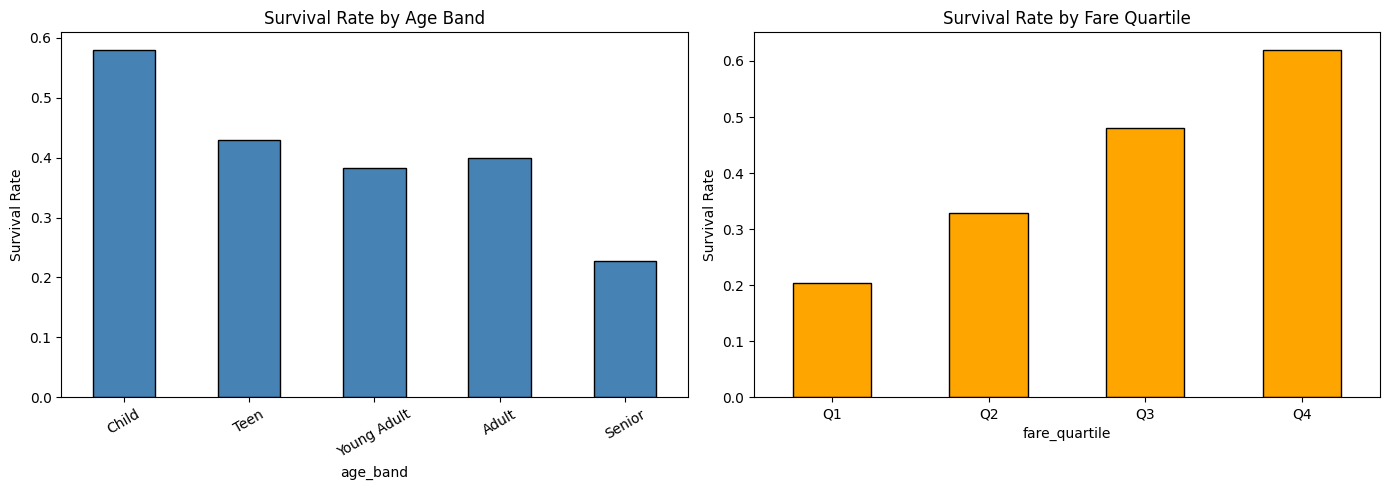

In [3]:
# Does survival rate differ meaningfully across age bands?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_fe.groupby('age_band', observed=True)['survived'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Survival Rate by Age Band')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=30)

df_fe.groupby('fare_quartile', observed=True)['survived'].mean().plot(
    kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Survival Rate by Fare Quartile')
axes[1].set_ylabel('Survival Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 2. Interaction Features

Products or ratios of two features capture relationships that neither feature captures alone.

In [4]:
# Family size = number of relatives on board
df_fe['family_size'] = df_fe['sibsp'] + df_fe['parch'] + 1  # +1 for self

# Is alone?
df_fe['is_alone'] = (df_fe['family_size'] == 1).astype(int)

# Fare per person
df_fe['fare_per_person'] = df_fe['fare'] / df_fe['family_size']

print("New interaction features:")
print(df_fe[['sibsp', 'parch', 'family_size', 'is_alone', 'fare', 'fare_per_person']].head(8))

New interaction features:
   sibsp  parch  family_size  is_alone     fare  fare_per_person
0      1      0            2         0   7.2500          3.62500
1      1      0            2         0  71.2833         35.64165
2      0      0            1         1   7.9250          7.92500
3      1      0            2         0  53.1000         26.55000
4      0      0            1         1   8.0500          8.05000
6      0      0            1         1  51.8625         51.86250
7      3      1            5         0  21.0750          4.21500
8      0      2            3         0  11.1333          3.71110


In [5]:
# Do interaction features correlate better with survival?
corr_with_target = df_fe[['age', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'survived']].corr()['survived'].drop('survived')
print("Correlation with 'survived':")
print(corr_with_target.sort_values(key=abs, ascending=False).round(3))

Correlation with 'survived':
fare               0.268
fare_per_person    0.236
is_alone          -0.196
age               -0.077
family_size        0.043
Name: survived, dtype: float64


---
## 3. Log Transform

For right-skewed features, a log transform compresses the scale and makes the distribution more symmetric — improving performance for models that assume normality.

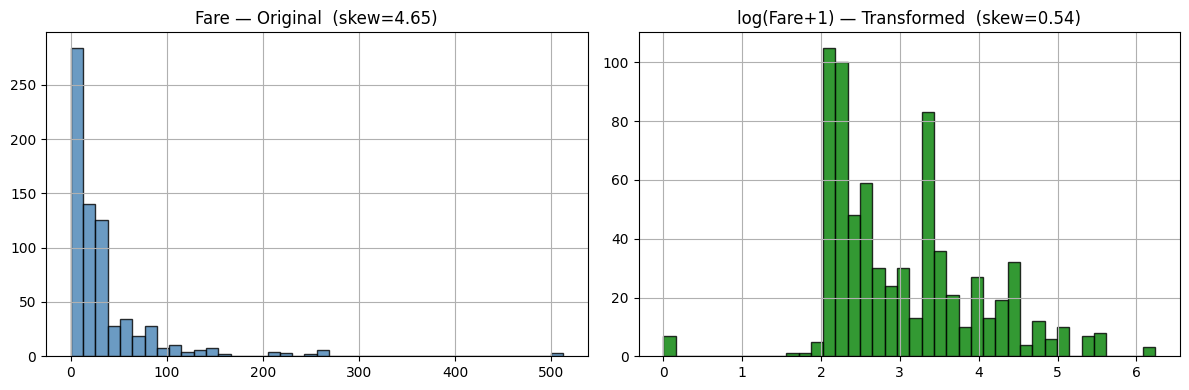

In [6]:
df_fe['log_fare'] = np.log1p(df_fe['fare'])  # log1p handles zero values gracefully

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_fe['fare'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title(f'Fare — Original  (skew={df_fe["fare"].skew():.2f})')

df_fe['log_fare'].hist(bins=40, ax=axes[1], color='green', edgecolor='black', alpha=0.8)
axes[1].set_title(f'log(Fare+1) — Transformed  (skew={df_fe["log_fare"].skew():.2f})')

plt.tight_layout()
plt.show()

---
## 4. Date Feature Extraction

Datetime columns can be decomposed into multiple numerical or categorical features that capture different temporal patterns.

In [7]:
dates = pd.DataFrame({
    'timestamp': pd.to_datetime([
        '2024-01-15 09:30', '2024-04-22 14:00', '2024-07-04 00:00',
        '2024-11-28 18:45', '2024-12-31 23:59'
    ])
})

dates['year']        = dates['timestamp'].dt.year
dates['month']       = dates['timestamp'].dt.month
dates['day_of_week'] = dates['timestamp'].dt.dayofweek  # 0=Monday
dates['day_of_year'] = dates['timestamp'].dt.dayofyear
dates['hour']        = dates['timestamp'].dt.hour
dates['is_weekend']  = (dates['day_of_week'] >= 5).astype(int)
dates['quarter']     = dates['timestamp'].dt.quarter

print(dates.to_string())

            timestamp  year  month  day_of_week  day_of_year  hour  is_weekend  quarter
0 2024-01-15 09:30:00  2024      1            0           15     9           0        1
1 2024-04-22 14:00:00  2024      4            0          113    14           0        2
2 2024-07-04 00:00:00  2024      7            3          186     0           0        3
3 2024-11-28 18:45:00  2024     11            3          333    18           0        4
4 2024-12-31 23:59:00  2024     12            1          366    23           0        4


---
## 5. Rare Category Grouping

Categories that appear very rarely provide almost no signal but add noise. Group them into an "Other" category before encoding.

In [8]:
# Simulate a high-cardinality column
np.random.seed(42)
cities = ['London'] * 120 + ['Paris'] * 80 + ['New York'] * 60 + \
         ['Tokyo'] * 30 + ['Sydney'] * 15 + ['Cairo'] * 8 + \
         ['Lima'] * 4 + ['Oslo'] * 3 + ['Nairobi'] * 2 + ['Reykjavik'] * 1
df_city = pd.DataFrame({'city': cities})

# Count each category
city_counts = df_city['city'].value_counts()
print("Category counts:")
print(city_counts)
print()

# Group rare categories (<2% of data)
threshold = 0.02 * len(df_city)
rare_cities = city_counts[city_counts < threshold].index
df_city['city_grouped'] = df_city['city'].apply(
    lambda x: 'Other' if x in rare_cities else x
)

print(f"Cities below threshold ({threshold:.0f} rows): {list(rare_cities)}")
print("\nAfter grouping:")
print(df_city['city_grouped'].value_counts())

Category counts:
city
London       120
Paris         80
New York      60
Tokyo         30
Sydney        15
Cairo          8
Lima           4
Oslo           3
Nairobi        2
Reykjavik      1
Name: count, dtype: int64

Cities below threshold (6 rows): ['Lima', 'Oslo', 'Nairobi', 'Reykjavik']

After grouping:
city_grouped
London      120
Paris        80
New York     60
Tokyo        30
Sydney       15
Other        10
Cairo         8
Name: count, dtype: int64


## Feature Engineering Summary

| Technique | What it does | Example |
|---|---|---|
| **Binning** | Continuous → ordinal categories | age → Child/Teen/Adult |
| **Interaction** | Combine features multiplicatively | sibsp + parch → family_size |
| **Log transform** | Reduce right skew | fare → log(fare+1) |
| **Date extraction** | Datetime → interpretable parts | timestamp → month, hour, is_weekend |
| **Rare grouping** | Reduce cardinality | Lagos, Oslo → Other |

**Validation**: always check whether engineered features actually correlate better with the target before keeping them.